<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Passport Page Detection</div>
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h2 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 20px 0; font-size: 1.8em; font-weight: 800; color: #2c3e50;">זיהוי עמוד הדרכון</h2>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 18px 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">שלב זה קולט את פלטי ה-OCR מכל שמונה הזוויות, מנתח עבור כל תמונה את התוצאות שהתקבלו בכל אחת מהן, ומפיק רשומה אחת המסכמת את התבניות שזוהו ואת ההכרעה באשר להימצאות דרכון בעמוד.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px; margin-bottom: 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">בסיס הזיהוי</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">התבניות פותחו על פי תקן ICAO Doc 9303, Part 4, המגדיר את מבנהו התקני של הדרכון. לפי התקן, תצלום בעל המסמך ואזור ה-MRZ (Machine Readable Zone – אזור קריא-מכונה המיועד לסריקה ממוחשבת) הם רכיבי חובה. ה-MRZ מסוג TD3 מורכב משתי שורות בנות 44 תווים כל אחת, והתו הראשון בו הוא P. בנוסף לכך, כללנו מספר מצומצם של שדות נבחרים, בפרט זיהוי של הימצאות שם המסמך ומספר הדרכון, כהוכחת יכולת ראשונית (PoC) וכמדד לבדיקת איכות התהליך.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px; margin-bottom: 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">כלל ההכרעה</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">לכל תבנית שאותרה מוקצה משקל מספרי, והציון המצטבר קובע את הסיווג: ציון 0 משמעותו שלא נמצא דרכון, ציון 1 מעיד כי נדרשת בדיקה טובה יותר של הדף, וציון 2 ומעלה קובע כי הדף מכיל דרכון. הדרישה לצירוף של יותר מסימן אחד, במקום הסתמכות על סימן יחיד, נועדה לצמצם זיהויי שווא.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 16px 20px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">היקף התוצאה</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">הזיהוי מתבסס על טקסט בלבד. תוצאה חיובית מצביעה על סבירות גבוהה לכך שהתמונה מכילה את עמוד הדרכון המרכזי, הכולל בהגדרתו את תצלום בעל המסמך, אך אין בה ניתוח חזותי של התמונה ואין בה קביעה של הימצאות פנים בפועל.</div>
</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 20px 24px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 8px;">מקורות</div>
<div style="direction: ltr !important; text-align: left !important; line-height: 2; color: #2c3e50; font-size: 0.95em;">
<div><a href="https://www.icao.int/sites/default/files/publications/DocSeries/9303_p4_cons_en.pdf">ICAO Doc 9303, Part 4 — Specifications for Machine Readable Passports</a></div>
<div><a href="https://link.springer.com/chapter/10.1007/978-3-642-03315-5_11">An Overview of Electronic Passport Security Features</a></div>
<div><a href="https://www.id4africa.com/2019/almanac/GEMALTO-Joseph-Leibenguth.pdf">Gemalto — Passport Security Report</a></div>
<div><a href="https://eoivienna.gov.in/public_files/assets/pdf/Passport_Photo_Requirements_230125.pdf">Passport Photo Requirements</a></div>
</div>
</div>

In [2]:
from pathlib import Path
import re
import unicodedata

import pandas as pd

INPUT_CSV = Path("ocr_8_angles.csv")
OUTPUT_CSV = Path("passport_detection_results.csv")

TEXT_COLUMNS = [
    "text_angle_000",
    "text_angle_045",
    "text_angle_090",
    "text_angle_135",
    "text_angle_180",
    "text_angle_225",
    "text_angle_270",
    "text_angle_315",
]
REQUIRED_COLUMNS = ["image_name", *TEXT_COLUMNS]

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Regex Pattern Database</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">מאגר תבניות הזיהוי</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">הזיהוי נשען על שש תבניות, שלכל אחת מהן משקל המשקף את מידת הייחודיות שלה לעמוד הדרכון. עבור כל תמונה נסרקות כל שמונה זוויות ה-OCR, ומשקלי התבניות שאותרו מסוכמים לכדי ציון אחד.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">תבנית שאותרה בכמה זוויות נספרת פעם אחת בלבד, כדי שריבוי הזוויות לא ינפח את הציון. הציון המצטבר מתורגם להכרעה: ציון 0 משמעותו שלא נמצא דרכון, ציון 1 מעיד כי נדרשת בדיקה טובה יותר של הדף, וציון 2 ומעלה קובע כי הדף מכיל דרכון.</div>
</div>

In [3]:
PATTERNS = [
    {
        "name": "td3_mrz_pair_strict",
        "target": "mrz_stream",
        "regex": r"P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<][MFX<][0-9]{6}[0-9<][A-Z0-9<]{14}[0-9<]{2}",
        "weight": 2,
        "kind": "mrz",
        "description": "Strict contiguous pair of ICAO TD3 passport MRZ lines (44 + 44 characters).",
    },
    {
        "name": "td3_mrz_upper_line",
        "target": "mrz_lines",
        "regex": r"(?m)^P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}$",
        "weight": 1,
        "kind": "mrz",
        "description": "Exact 44-character upper TD3 line; P is the passport document code.",
    },
    {
        "name": "td3_mrz_lower_line",
        "target": "mrz_lines",
        "regex": r"(?m)^[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<][MFX<][0-9]{6}[0-9<][A-Z0-9<]{14}[0-9<]{2}$",
        "weight": 1,
        "kind": "mrz",
        "description": "Exact 44-character lower TD3 line with document number, nationality, dates, sex and check digits.",
    },
    {
        "name": "passport_word_exact",
        "target": "text_flat",
        "regex": r"\b(?:PASSPORT|PASSEPORT|PASAPORTE)\b",
        "weight": 1,
        "kind": "passport_label",
        "description": "ICAO VIZ passport heading in English, French or Spanish.",
    },
    {
        "name": "passport_word_ocr_tolerant",
        "target": "text_flat",
        "regex": r"\b(?:PAS5PORT|PA5SPORT|PASSP0RT|PASSEP0RT|PASAP0RTE)\b",
        "weight": 1,
        "kind": "passport_label",
        "description": "Common OCR substitutions in the passport heading S->5 and O->0.",
    },
    {
        "name": "passport_number_label",
        "target": "text_flat",
        "regex": r"\b(?:PASSPORT|PASSEPORT|PASAPORTE)\s*(?:NO|NUMBER|NUMERO|N[O0°º])\b",
        "weight": 2,
        "kind": "passport_label",
        "description": "Passport/document number caption.",
    },
]

patterns_df = pd.DataFrame(PATTERNS)
patterns_df[["name", "target", "weight", "kind", "regex", "description"]]

,name,target,weight,kind,regex,description
0,td3_mrz_pair_strict,mrz_stream,2,mrz,P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}[A-Z0-9<]{9}[0-9<...,Strict contiguous pair of ICAO TD3 passport MR...
1,td3_mrz_upper_line,mrz_lines,1,mrz,(?m)^P[A-Z0-9<][A-Z<]{3}[A-Z<]{39}$,Exact 44-character upper TD3 line; P is the pa...
2,td3_mrz_lower_line,mrz_lines,1,mrz,(?m)^[A-Z0-9<]{9}[0-9<][A-Z<]{3}[0-9]{6}[0-9<]...,Exact 44-character lower TD3 line with documen...
3,passport_word_exact,text_flat,1,passport_label,\b(?:PASSPORT|PASSEPORT|PASAPORTE)\b,"ICAO VIZ passport heading in English, French o..."
4,passport_word_ocr_tolerant,text_flat,1,passport_label,\b(?:PAS5PORT|PA5SPORT|PASSP0RT|PASSEP0RT|PASA...,Common OCR substitutions in the passport headi...
5,passport_number_label,text_flat,2,passport_label,\b(?:PASSPORT|PASSEPORT|PASAPORTE)\s*(?:NO|NUM...,Passport/document number caption.


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">עמודת <code style="direction: ltr; display: inline-block;">target</code> מציינת באיזה ייצוג של הטקסט כל תבנית מחפשת: <code style="direction: ltr; display: inline-block;">mrz_lines</code> הוא שורות באורך המתאים ל-MRZ, <code style="direction: ltr; display: inline-block;">mrz_stream</code> הוא הטקסט כולו ללא רווחים, ו-<code style="direction: ltr; display: inline-block;">text_flat</code> הוא הטקסט החופשי שבעמוד.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Normalization and Matching</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">נרמול הטקסט והתאמת התבניות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">פלט ה-OCR אינו אחיד, ולכן הטקסט עובר נרמול לפני ההתאמה: המרה לאותיות גדולות, הסרת סימני ניקוד, ותיקון תווים דמויי סוגר שהמנוע מחזיר לעיתים במקום תו המילוי של אזור ה-MRZ.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">מהטקסט המנורמל נגזרים שלושה ייצוגים, וכל תבנית נבדקת מול הייצוג המתאים לה: טקסט רציף לאיתור מילים ותוויות; שורות שאורכן תואם לשורת MRZ ולאחר שנוקו מתווים שאינם אותיות, ספרות או תו מילוי ורצף התווים המלא, המאפשר זיהוי גם כאשר שתי שורות ה-MRZ הוחזרו ללא הפרדה ביניהן.</div>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">כל תבנית תורמת את משקלה פעם אחת בלבד לכל תמונה, גם אם אותרה בכמה זוויות.

In [3]:
FILLER_TRANSLATION = str.maketrans({
    "«": "<", "‹": "<", "＜": "<", "〈": "<", "⟨": "<"
})

def normalize_ocr(value):
    if pd.isna(value):
        return ""
    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.upper().translate(FILLER_TRANSLATION)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text

def build_search_targets(value):
    text = normalize_ocr(value)
    text_flat = re.sub(r"\s+", " ", text).strip()

    # Remove spaces/punctuation introduced inside OCR-B lines. Restrict candidate
    # lengths to avoid treating ordinary short text lines as MRZ lines.
    mrz_candidates = []
    for line in text.splitlines():
        compact = re.sub(r"[^A-Z0-9<]", "", line)
        if 30 <= len(compact) <= 50:
            mrz_candidates.append(compact)

    return {
        "text_flat": text_flat,
        "mrz_lines": "\n".join(mrz_candidates),
        # The stream also catches OCR output where both MRZ lines were returned
        # without a newline. A full 88-character structural match is required.
        "mrz_stream": re.sub(r"[^A-Z0-9<]", "", text),
    }

COMPILED_PATTERNS = {
    item["name"]: re.compile(item["regex"]) for item in PATTERNS
}
PATTERN_BY_NAME = {item["name"]: item for item in PATTERNS}
PATTERN_ORDER = [item["name"] for item in PATTERNS]
def match_one_text(value):
    targets = build_search_targets(value)
    matched = {
        item["name"]
        for item in PATTERNS
        if COMPILED_PATTERNS[item["name"]].search(targets[item["target"]])
    }

    # Exact and OCR-tolerant passport words represent the same evidence.
    if "passport_word_exact" in matched:
        matched.discard("passport_word_ocr_tolerant")
    return matched

def classify_row(row):
    matched_angles = {}
    all_matches = set()

    for column in TEXT_COLUMNS:
        angle_matches = match_one_text(row[column])
        if angle_matches:
            matched_angles[column] = sorted(angle_matches)
            all_matches.update(angle_matches)

    # Apply exact-over-tolerant de-duplication again across angles.
    if "passport_word_exact" in all_matches:
        all_matches.discard("passport_word_ocr_tolerant")

    score = sum(PATTERN_BY_NAME[name]["weight"] for name in all_matches)
    verdict = "YES" if score >= 2 else "MAYBE" if score == 1 else "NO"

    ordered_matches = [name for name in PATTERN_ORDER if name in all_matches]
    return pd.Series({
        "matched_pattern_names": "; ".join(ordered_matches),
        "verdict": verdict,
        "score": score,
        "matched_angles": matched_angles,
    })

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Classify Images</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">סיווג התמונות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">כלל הסיווג מופעל על כל שורה בטבלת תוצאות ה-OCR, ופלטו נשמר בשתי טבלאות הנבדלות ברמת הפירוט ובייעודן.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">טבלת התוצאות - <code style="direction: ltr; display: inline-block;">result_df</code></div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">הפלט הסופי של השלב, בשלוש עמודות: שם התמונה, שמות התבניות שאותרו וההכרעה. הטבלה נשמרת לקובץ CSV ומהווה את תוצר הסיווג המשמש את שלבי ההמשך.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">טבלת האבחון - <code style="direction: ltr; display: inline-block;">diagnostics_df</code></div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מכילה בנוסף את הציון המספרי ואת פירוט ההתאמות ברמת הזווית הבודדת, ונשמרת בזיכרון בלבד. פירוט זה נדרש לכיול סף ההכרעה ולניתוח שגיאות, שכן הוא מאפשר לבחון מדוע תמונה סווגה כפי שסווגה ואילו זוויות תרמו לכך.</div>
</div>
</div>

In [4]:
ocr_df = pd.read_csv(INPUT_CSV)
ocr_df[TEXT_COLUMNS] = ocr_df[TEXT_COLUMNS].fillna("").astype(str)
classification_df = ocr_df.apply(classify_row, axis=1)

result_df = pd.concat(
    [
        ocr_df[["image_name"]].reset_index(drop=True),
        classification_df[["matched_pattern_names", "verdict"]].reset_index(drop=True),
    ],
    axis=1,
)

diagnostics_df = pd.concat(
    [
        ocr_df[["image_name"]].reset_index(drop=True),
        classification_df.reset_index(drop=True),
    ],
    axis=1,
)

result_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result_df):,} classifications to {OUTPUT_CSV}")
print(result_df["verdict"].value_counts(dropna=False))

Saved 141 classifications to passport_detection_results_v2.csv
verdict
NO       128
MAYBE     11
YES        2
Name: count, dtype: int64


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Detection Results Visualization</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">הצגה גרפית של תוצאות הזיהוי</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; line-height: 1.8; color: #2c3e50;">תוצאות הסיווג מוצגות באמצעות התפלגות ההכרעות הסופיות, הממחישה את שיעור ההצלחה הכללי של התהליך. לצד זאת, מוצגת תדירות ההופעה של כל תבנית (Pattern) כדי לבחון את המעורבות של כל חוק חיפוש.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">בחינת תדירות התבניות חושפת אילו אינדיקטורים תרמו בפועל לזיהוי, ומסייעת באיתור תבניות שאינן יעילות ודורשות כיול מחדש.</div>
</div>
</div>

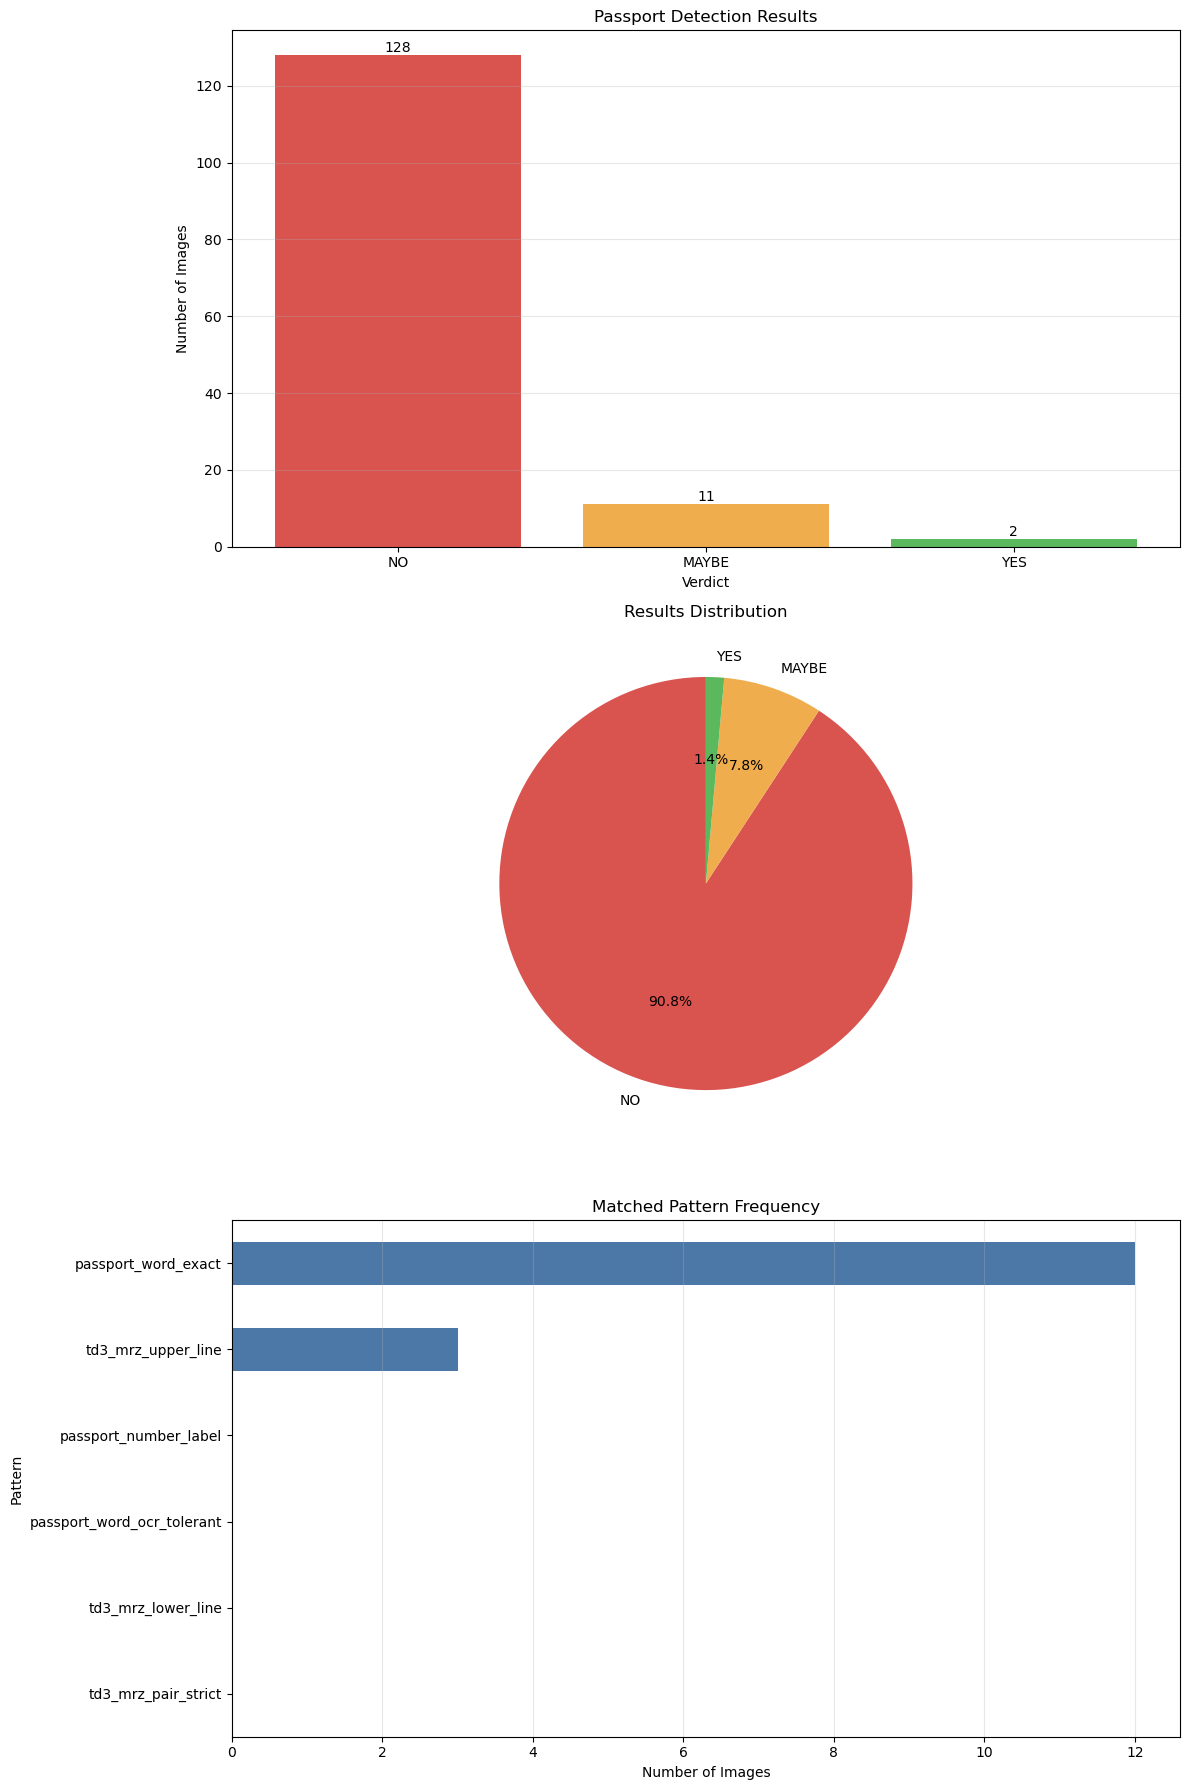

In [5]:
import matplotlib.pyplot as plt

if result_df.empty:
    raise ValueError("result_df is empty")

verdict_order = ["NO", "MAYBE", "YES"]
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]

verdict_counts = (
    result_df["verdict"]
    .value_counts()
    .reindex(verdict_order, fill_value=0)
)

pattern_counts = (
    result_df["matched_pattern_names"]
    .fillna("")
    .str.split("; ")
    .explode()
)

pattern_counts = (
    pattern_counts[pattern_counts.ne("")]
    .value_counts()
    .reindex(
        [pattern["name"] for pattern in PATTERNS],
        fill_value=0
    )
    .sort_values()
)

# Three rows, one column
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Verdict counts
bars = axes[0].bar(
    verdict_counts.index,
    verdict_counts.values,
    color=colors
)

axes[0].bar_label(bars)
axes[0].set_title("Passport Detection Results")
axes[0].set_xlabel("Verdict")
axes[0].set_ylabel("Number of Images")
axes[0].grid(axis="y", alpha=0.3)

# 2. Verdict percentages
axes[1].pie(
    verdict_counts.values,
    labels=verdict_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)

axes[1].set_title("Results Distribution")

# 3. Matched-pattern frequency
pattern_counts.plot(
    kind="barh",
    ax=axes[2],
    color="#4c78a8"
)

axes[2].set_title("Matched Pattern Frequency")
axes[2].set_xlabel("Number of Images")
axes[2].set_ylabel("Pattern")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מתוך 141 התמונות, 128 סווגו כ-NO (אין דרכון), 11 כ-MAYBE (ייתכן שיש) ורק 2 כ-YES (יש דרכון). כלומר בכ-91% מהמקרים לא נמצא אף סימן מזהה, ובאלה שבהם כן נמצא  לרוב סימן יחיד בלבד, שאינו מספיק להכרעה.</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50; margin-top: 10px;">פילוח התבניות מסביר מדוע: מתוך שש התבניות שהוגדרו, רק שתיים נמצאו בכלל  המילה PASSPORT ושורת ה-MRZ העליונה. ארבע התבניות הנותרות לא נמצאו באף תמונה.</div>
</div>